<a href="https://colab.research.google.com/github/wanchenlang-max/econ5200-lab/blob/lab16/lab16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install wbgapi -q

import pandas as pd
import numpy as np
import wbgapi as wb
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, lasso_path

In [4]:
indicators = [
    'NY.GDP.MKTP.KD.ZG',
    'FP.CPI.TOTL.ZG',
    'BX.KLT.DINV.WD.GD.ZS',
    'NE.TRD.GNFS.ZS',
    'GC.DOD.TOTL.GD.ZS',
    'SL.UEM.TOTL.ZS',

    'SP.POP.GROW',
    'NE.GDI.TOTL.ZS',
    'FR.INR.RINR',
    'NV.AGR.TOTL.ZS',
    'NV.IND.TOTL.ZS',
    'NV.SRV.TOTL.ZS',
    'GC.XPN.TOTL.GD.ZS',
    'NE.EXP.GNFS.ZS',
    'NE.IMP.GNFS.ZS',
    'BX.KLT.DINV.CD.WD',
    'SI.POV.GINI',
    'SP.DYN.LE00.IN',
    'SE.XPD.TOTL.GD.ZS',
    'SH.XPD.CHEX.GD.ZS'
]

print("Querying World Bank API...")


df_api = wb.data.DataFrame(indicators, time=2022, skipBlanks=True, columns='series')

df_clean = df_api.dropna()


y = df_clean['NY.GDP.MKTP.KD.ZG']
X_raw = df_clean.drop(columns=['NY.GDP.MKTP.KD.ZG'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print("Raw API dataframe shape:", df_api.shape)
print("Clean dataframe shape after dropna():", df_clean.shape)
print(f"API Ingestion Complete. Feature matrix shape: {X_scaled.shape}")
print(f"Target vector shape: {y.shape}")

print("\nPreview of cleaned data:")
display(df_clean.head())

Querying World Bank API...
Raw API dataframe shape: (265, 20)
Clean dataframe shape after dropna(): (11, 20)
API Ingestion Complete. Feature matrix shape: (11, 19)
Target vector shape: (11,)

Preview of cleaned data:


,BX.KLT.DINV.CD.WD,BX.KLT.DINV.WD.GD.ZS,FP.CPI.TOTL.ZG,FR.INR.RINR,GC.DOD.TOTL.GD.ZS,GC.XPN.TOTL.GD.ZS,NE.EXP.GNFS.ZS,NE.GDI.TOTL.ZS,NE.IMP.GNFS.ZS,NE.TRD.GNFS.ZS,NV.AGR.TOTL.ZS,NV.IND.TOTL.ZS,NV.SRV.TOTL.ZS,NY.GDP.MKTP.KD.ZG,SE.XPD.TOTL.GD.ZS,SH.XPD.CHEX.GD.ZS,SI.POV.GINI,SL.UEM.TOTL.ZS,SP.DYN.LE00.IN,SP.POP.GROW
economy,,,,,,,,,,,,,,,,,,,,
ARM,9.756589e+08,4.999916,8.640911,3.457429,46.551823,21.162755,51.570920,22.255132,52.307709,103.878629,10.146704,25.437097,55.616202,12.600000,2.491900,9.962112,27.9,13.451,74.765854,0.232656
BRA,7.550104e+10,3.868032,9.280106,28.396093,79.102322,31.641436,19.630765,18.088220,19.185301,38.816066,5.767475,22.819457,58.087231,3.016694,5.619230,9.387395,52.0,9.231,74.872000,0.360181
CHE,-1.241405e+10,-1.498360,2.835028,-0.381724,17.586186,16.469270,76.139768,24.817343,62.360931,138.500699,0.616380,24.543382,72.171350,3.044061,4.924190,11.599118,33.8,4.122,83.604878,0.829927
GEO,2.257737e+09,9.036525,11.898165,5.104593,42.969393,24.936453,52.478879,24.066663,62.216558,114.695438,6.632355,21.329780,59.049246,10.958532,3.754980,8.296343,33.5,11.621,74.141000,0.104890
KGZ,5.484900e+07,0.451993,13.922909,-0.829301,47.085481,23.831946,46.337272,35.640688,87.449446,133.786718,10.996806,24.194142,51.015543,8.967505,7.168844,5.048749,26.4,4.767,72.048780,1.793655


In [5]:


ols_model = LinearRegression().fit(X_scaled, y)

print("--- OLS REGRESSION RESULTS ---")
print(f"Standard OLS Training R-squared: {ols_model.score(X_scaled, y):.4f}")
print("Notice how the model effectively 'memorizes' the dataset.")

ols_coef_df = pd.DataFrame({
    'Variable': X_raw.columns,
    'OLS_Coefficient': ols_model.coef_
}).sort_values(by='OLS_Coefficient', key=np.abs, ascending=False)

print("\nTop OLS coefficients by absolute value:")
display(ols_coef_df.head(10))

--- OLS REGRESSION RESULTS ---
Standard OLS Training R-squared: 1.0000
Notice how the model effectively 'memorizes' the dataset.

Top OLS coefficients by absolute value:


,Variable,OLS_Coefficient
16,SL.UEM.TOTL.ZS,3.595755
18,SP.POP.GROW,2.319356
15,SI.POV.GINI,-1.828089
14,SH.XPD.CHEX.GD.ZS,-1.749206
5,GC.XPN.TOTL.GD.ZS,-1.005549
11,NV.IND.TOTL.ZS,-0.805200
7,NE.GDI.TOTL.ZS,-0.774995
1,BX.KLT.DINV.WD.GD.ZS,0.745064
2,FP.CPI.TOTL.ZG,-0.686039
17,SP.DYN.LE00.IN,0.605505


In [6]:

lasso_model = LassoCV(cv=5, random_state=42, max_iter=10000).fit(X_scaled, y)

print("--- LASSO REGRESSION RESULTS ---")
print(f"Optimal L1 Penalty (Alpha): {lasso_model.alpha_:.4f}")

surviving_features = np.sum(lasso_model.coef_ != 0)
eliminated_features = np.sum(lasso_model.coef_ == 0)

print(f"\nFeatures Retained (Signal): {surviving_features}")
print(f"Features Eliminated (Noise): {eliminated_features}")

active_vars = X_raw.columns[lasso_model.coef_ != 0]
active_coefs = lasso_model.coef_[lasso_model.coef_ != 0]

print("\nTop Surviving Macroeconomic Indicators:")
for var, coef in zip(active_vars, active_coefs):
    print(f"{var}: {coef:.4f}")

lasso_coef_df = pd.DataFrame({
    'Variable': X_raw.columns,
    'Lasso_Coefficient': lasso_model.coef_
})

lasso_coef_df['Selected_By_Lasso'] = lasso_coef_df['Lasso_Coefficient'] != 0
lasso_coef_df = lasso_coef_df.sort_values(by='Lasso_Coefficient', key=np.abs, ascending=False)

print("\nFull Lasso coefficient table:")
display(lasso_coef_df)

--- LASSO REGRESSION RESULTS ---
Optimal L1 Penalty (Alpha): 1.0527

Features Retained (Signal): 3
Features Eliminated (Noise): 16

Top Surviving Macroeconomic Indicators:
GC.XPN.TOTL.GD.ZS: -0.8835
SL.UEM.TOTL.ZS: 2.5681
SP.POP.GROW: 0.3473

Full Lasso coefficient table:


,Variable,Lasso_Coefficient,Selected_By_Lasso
16,SL.UEM.TOTL.ZS,2.568094,True
5,GC.XPN.TOTL.GD.ZS,-0.883533,True
18,SP.POP.GROW,0.347270,True
2,FP.CPI.TOTL.ZG,-0.000000,False
1,BX.KLT.DINV.WD.GD.ZS,0.000000,False
0,BX.KLT.DINV.CD.WD,0.000000,False
3,FR.INR.RINR,-0.000000,False
7,NE.GDI.TOTL.ZS,0.000000,False
8,NE.IMP.GNFS.ZS,0.000000,False
4,GC.DOD.TOTL.GD.ZS,0.000000,False


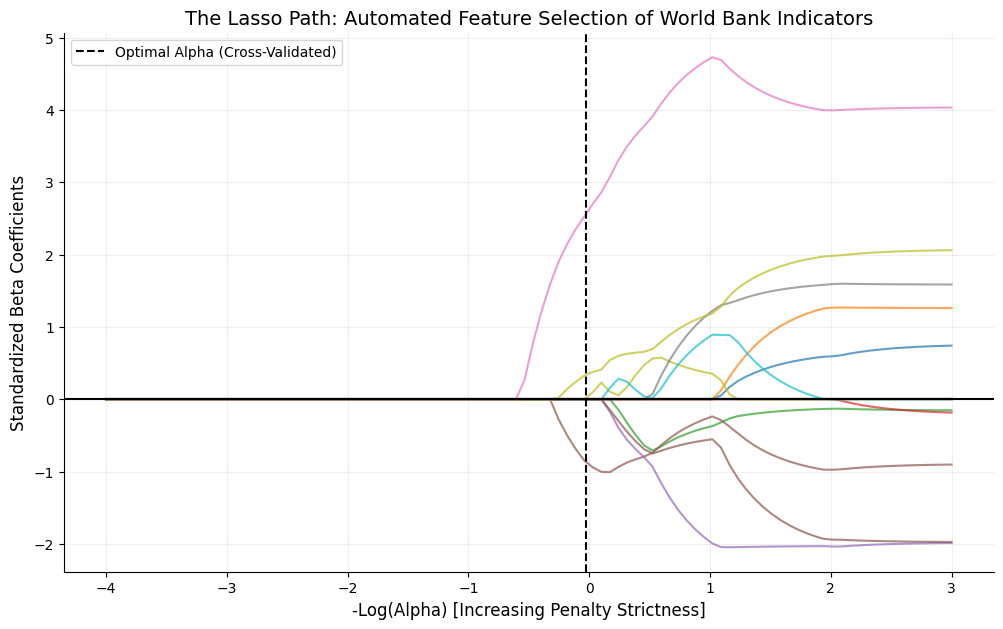

In [11]:

alphas_lasso, coefs_lasso, _ = lasso_path(X_scaled, y, alphas=alphas_to_test, max_iter=10000)

plt.figure(figsize=(12, 7))

for i in range(coefs_lasso.shape[0]):
    plt.plot(-np.log10(alphas_lasso), coefs_lasso[i, :], alpha=0.7)


plt.axvline(
    x=-np.log10(lasso_model.alpha_),
    color='black',
    linestyle='--',
    label='Optimal Alpha (Cross-Validated)'
)

plt.title('The Lasso Path: Automated Feature Selection of World Bank Indicators', fontsize=14)
plt.xlabel('-Log(Alpha) [Increasing Penalty Strictness]', fontsize=12)
plt.ylabel('Standardized Beta Coefficients', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5)
plt.legend()


plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(alpha=0.2)

plt.show()

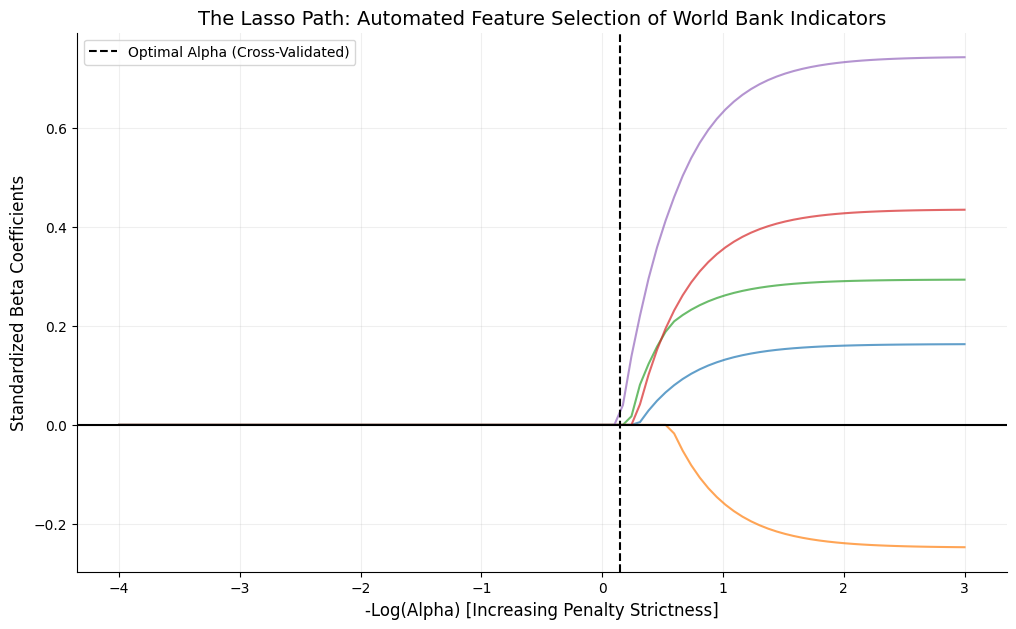

In [ ]:

alphas_lasso, coefs_lasso, _ = lasso_path(X_scaled, y, alphas=alphas_to_test, max_iter=10000)

plt.figure(figsize=(12, 7))

for i in range(coefs_lasso.shape[0]):
    plt.plot(-np.log10(alphas_lasso), coefs_lasso[i, :], alpha=0.7)

plt.axvline(x=-np.log10(lasso_model.alpha_), color='black', linestyle='--', label='Optimal Alpha (Cross-Validated)')

plt.title('The Lasso Path: Automated Feature Selection of World Bank Indicators', fontsize=14)
plt.xlabel('-Log(Alpha) [Increasing Penalty Strictness]', fontsize=12)
plt.ylabel('Standardized Beta Coefficients', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5)
plt.legend()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(alpha=0.2)

plt.show()